In [1]:
from pydrawnet.renderers import SeqRenderer, FreeformRenderer
from pydrawnet import layers, operations
import math
import matplotlib.pyplot as plt

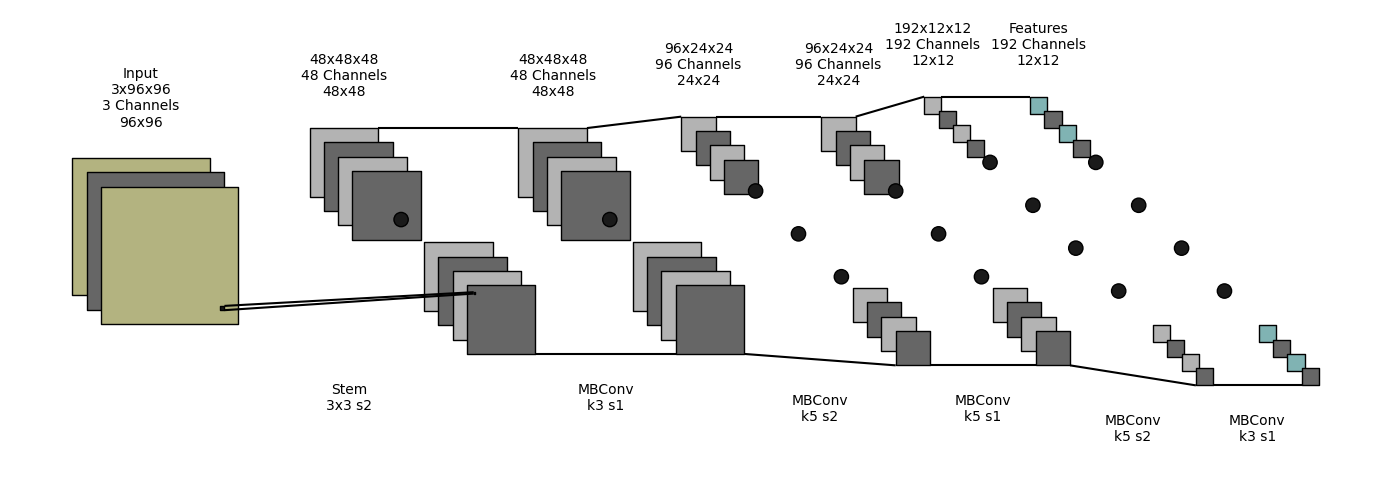

In [ ]:
from pydrawnet.renderers import SeqRenderer
from pydrawnet import layers, operations


SR = SeqRenderer()

# PCAM input is 96x96 RGB; ERTECNet uses widths (48, 96, 192) and strides (2, 2, 2)
SR.add_layer(layers.Layer2D(3, 96, 96, "Input\n3x96x96", color_light=(0.7, 0.7, 0.5)))

# Stem: Conv3x3, stride 2 -> 48x48x48
SR.add_operation(operations.Conv2dOp((3, 3), stride=2, label="Stem\n3x3 s2", label_only=True))
SR.add_layer(layers.Layer2D(48, 48, 48, "48x48x48", limited=12, end_channels=4))

# MBConv blocks (ECA + SiLU)
SR.add_operation(operations.LinearOp("MBConv\nk3 s1"))
SR.add_layer(layers.Layer2D(48, 48, 48, "48x48x48", limited=12, end_channels=4))

SR.add_operation(operations.LinearOp("MBConv\nk5 s2"))
SR.add_layer(layers.Layer2D(96, 24, 24, "96x24x24", limited=16, end_channels=4))

SR.add_operation(operations.LinearOp("MBConv\nk5 s1"))
SR.add_layer(layers.Layer2D(96, 24, 24, "96x24x24", limited=16, end_channels=4))

SR.add_operation(operations.LinearOp("MBConv\nk5 s2"))
SR.add_layer(layers.Layer2D(192, 12, 12, "192x12x12", limited=20, end_channels=4))

SR.add_operation(operations.LinearOp("MBConv\nk3 s1"))
SR.add_layer(layers.Layer2D(192, 12, 12, "Features", limited=20, end_channels=4, color_light=(0.5, 0.7, 0.7)))

SR.make_figure((400, 6))
SR.render(50, 50, text_y_offset=20, offset_from_limits=False)


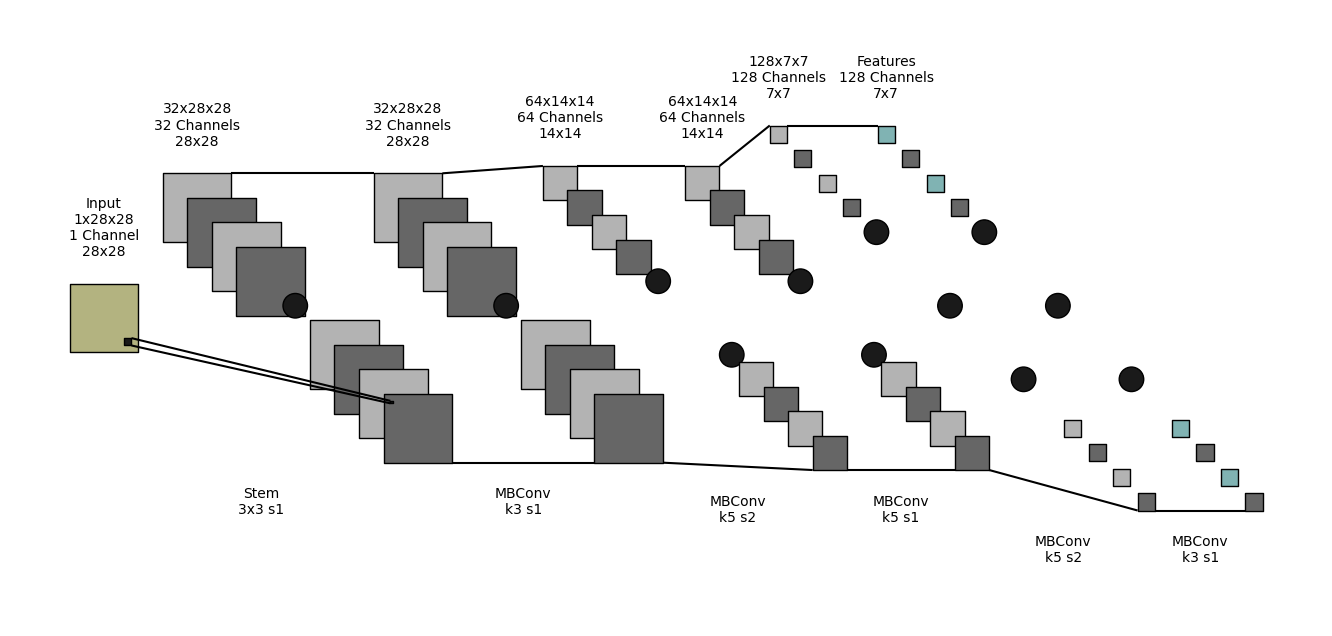

In [ ]:
from pydrawnet.renderers import SeqRenderer
from pydrawnet import layers, operations

SR = SeqRenderer()

# MNIST input is 28x28 grayscale; ERTECNet uses widths (32, 64, 128) and strides (1, 2, 2)
SR.add_layer(layers.Layer2D(1, 28, 28, "Input\n1x28x28", color_light=(0.7, 0.7, 0.5)))

# Stem: Conv3x3, stride 1 -> 32x28x28
SR.add_operation(operations.Conv2dOp((3, 3), stride=1, label="Stem\n3x3 s1", label_only=True))
SR.add_layer(layers.Layer2D(32, 28, 28, "32x28x28", limited=10, end_channels=4))

# MBConv blocks (ECA + SiLU)
SR.add_operation(operations.LinearOp("MBConv\nk3 s1"))
SR.add_layer(layers.Layer2D(32, 28, 28, "32x28x28", limited=10, end_channels=4))

SR.add_operation(operations.LinearOp("MBConv\nk5 s2"))
SR.add_layer(layers.Layer2D(64, 14, 14, "64x14x14", limited=12, end_channels=4))

SR.add_operation(operations.LinearOp("MBConv\nk5 s1"))
SR.add_layer(layers.Layer2D(64, 14, 14, "64x14x14", limited=12, end_channels=4))

SR.add_operation(operations.LinearOp("MBConv\nk5 s2"))
SR.add_layer(layers.Layer2D(128, 7, 7, "128x7x7", limited=16, end_channels=4))

SR.add_operation(operations.LinearOp("MBConv\nk3 s1"))
SR.add_layer(layers.Layer2D(128, 7, 7, "Features", limited=16, end_channels=4, color_light=(0.5, 0.7, 0.7)))

SR.make_figure((200, 8))
SR.render(10, 30, text_y_offset=10, offset_from_limits=False)